# EMC Parameter Trustworthiness

- **Issue:** A large fraction of EMC mass/radius pairs are not independent measurements. One was derived from the other using a power-law M-R relation inside EU or OEC.
- **Explanation:** EU/OEC store derived values in the same column as measured ones with no flag. The `_url` label is just the source catalog name (`'oec'`/`'eu'`), not a paper reference.
- **Implication:** EMC is excellent for crossmatching (identifier completeness). For M-R science, filter to NASA-won bibcode entries only.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from astropy import units as u

mpl.rcParams['figure.dpi'] = 150

emc = pd.read_csv('./input/exo-mercat.csv', low_memory=False)

rjup_to_rearth = u.R_jup.to(u.R_earth)
mjup_to_mearth = u.M_jup.to(u.M_earth)

r_all = pd.to_numeric(emc['r'],        errors='coerce') * rjup_to_rearth
m_all = pd.to_numeric(emc['bestmass'], errors='coerce') * mjup_to_mearth
both_def = (r_all > 0) & (m_all > 0)

r_urls  = emc['r_url'].fillna('').astype(str)
bm_urls = emc['bestmass_url'].fillna('').astype(str)

def is_bibcode(s):
    return bool(re.match(r'^\d{4}', str(s)))

# Restrict to entries with both r and bestmass defined
m_sel  = m_all[both_def].to_numpy()
r_sel  = r_all[both_def].to_numpy()
r_url  = r_urls[both_def].to_numpy()
bm_url = bm_urls[both_def].to_numpy()

bib_mask = np.array([is_bibcode(s) for s in r_url])
oec_mask = r_url == 'oec'
eu_mask  = r_url == 'eu'

# Smoking-gun case: Kepler photometric radii (2022ApJ...926..120V) paired with OEC-derived masses
kep_oec_mask = (r_url == '2022ApJ...926..120V') & (bm_url == 'oec')

print(f'Entries with both r and bestmass defined: {both_def.sum()}')
print(f'  r_url = NASA bibcode: {bib_mask.sum()}')
print(f'  r_url = oec:          {oec_mask.sum()}')
print(f'  r_url = eu:           {eu_mask.sum()}')
print(f'  Kepler+OEC case:      {kep_oec_mask.sum()}')

Entries with both r and bestmass defined: 2530
  r_url = NASA bibcode: 1143
  r_url = oec:          438
  r_url = eu:           746
  Kepler+OEC case:      128


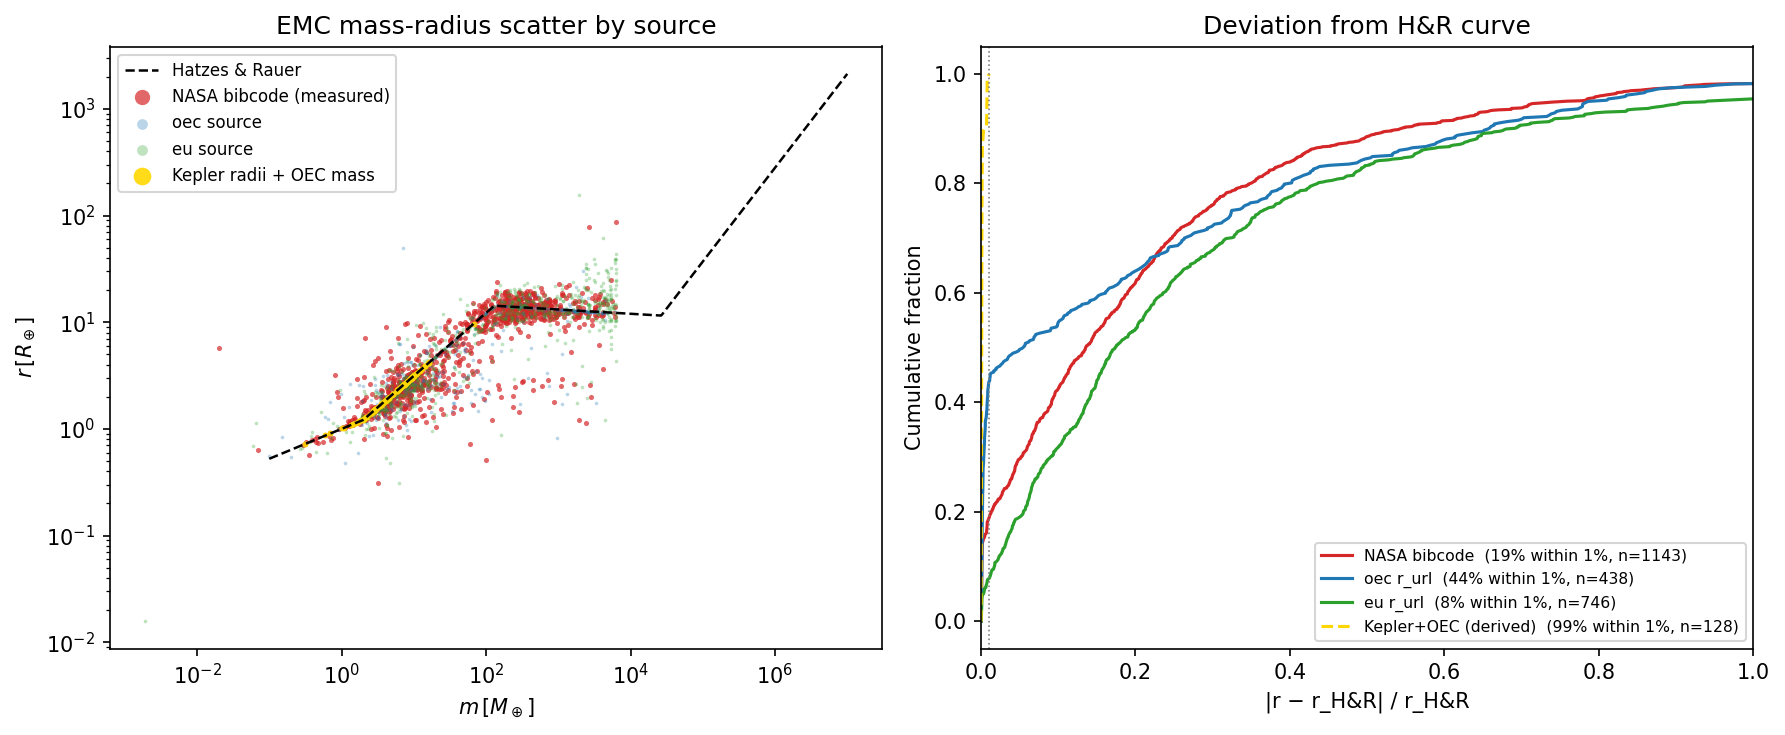

Kepler+OEC entries — bestmass_min is NaN (no uncertainty, i.e. derived): 128 / 128


In [2]:
# Hatzes & Rauer (2015) piecewise M-R relation, anchored at (1 M_earth, 1 R_earth)
_M1, _M2, _M3 = 2.0, 0.41 * mjup_to_mearth, 0.080 * 333_000
_A0 = 1.0
_A1 = _A0 * _M1 ** (0.28 - 0.59)
_A2 = _A1 * _M2 ** (0.59 - (-0.04))
_A3 = _A2 * _M3 ** ((-0.04) - 0.88)

def mass_radius_relation(m_earth):
    m = np.asarray(m_earth, dtype=float)
    r = np.empty_like(m)
    r[m <= _M1]                         = _A0 * m[m <= _M1] ** 0.28
    s2 = (m > _M1) & (m <= _M2);        r[s2] = _A1 * m[s2] ** 0.59
    s3 = (m > _M2) & (m <= _M3);        r[s3] = _A2 * m[s3] ** (-0.04)
    r[m > _M3]                          = _A3 * m[m > _M3] ** 0.88
    return r

r_predicted = mass_radius_relation(m_sel)
rel_dev     = np.abs(r_sel - r_predicted) / r_predicted

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── left: M-R scatter coloured by source ─────────────────────────────────────
ax = axes[0]
m_curve = np.logspace(-1, 7, 600)
ax.plot(m_curve, mass_radius_relation(m_curve), 'k--', lw=1.2, label='Hatzes & Rauer', zorder=5)

for label, mask, color, alpha, size in [
    ('NASA bibcode (measured)',  bib_mask,     '#d62728', 0.7, 6),
    ('oec source',               oec_mask,     '#1f77b4', 0.3, 3),
    ('eu source',                eu_mask,      '#2ca02c', 0.3, 3),
    ('Kepler radii + OEC mass',  kep_oec_mask, 'gold',    0.9, 8),
]:
    ax.scatter(m_sel[mask], r_sel[mask], s=size, alpha=alpha, color=color,
               label=label, linewidths=0)

ax.set(xscale='log', yscale='log',
       xlabel=r'$m\,[M_\oplus]$', ylabel=r'$r\,[R_\oplus]$',
       title='EMC mass-radius scatter by source')
ax.legend(markerscale=3, fontsize=8)

# ── right: CDF of deviation from H&R curve ───────────────────────────────────
ax2 = axes[1]
for label, mask, color, ls in [
    ('NASA bibcode',           bib_mask,     '#d62728', '-'),
    ('oec r_url',              oec_mask,     '#1f77b4', '-'),
    ('eu r_url',               eu_mask,      '#2ca02c', '-'),
    ('Kepler+OEC (derived)',   kep_oec_mask, 'gold',    '--'),
]:
    if mask.sum() > 0:
        sorted_dev = np.sort(rel_dev[mask])
        frac_within_1pct = (sorted_dev < 0.01).mean()
        ax2.plot(sorted_dev, np.linspace(0, 1, len(sorted_dev)),
                 color=color, ls=ls,
                 label=f'{label}  ({frac_within_1pct:.0%} within 1%, n={mask.sum()})')

ax2.axvline(0.01, color='gray', lw=0.8, ls=':')
ax2.set(xlim=(0, 1),
        xlabel='|r − r_H&R| / r_H&R',
        ylabel='Cumulative fraction',
        title='Deviation from H&R curve')
ax2.legend(fontsize=7.5)

plt.tight_layout()
plt.show()

# Verify: Kepler+OEC entries have no mass uncertainty (derived, not measured)
kep_oec_rows = emc[both_def][kep_oec_mask]
bm_min = pd.to_numeric(kep_oec_rows['bestmass_min'], errors='coerce')
print(f'Kepler+OEC entries — bestmass_min is NaN (no uncertainty, i.e. derived): '
      f'{bm_min.isna().sum()} / {kep_oec_mask.sum()}')